In [1]:
import os
os.environ['CUDA_LAUNCH_BLOCKING'] = '1'

In [2]:
import pandas as pd 

In [3]:
data = pd.read_csv(r"/home/ronodeep/thesisfinal-1/all_images_mapping_with_types.csv")

In [4]:
data.head()

,Case Number,Original Filename,Original Path,New Filename,Image Type
0,1,AAAW3.jpg,Case 001/AAAW3.jpg,AAAW3.jpg,After acetic acid
1,1,AAAW2.jpg,Case 001/AAAW2.jpg,AAAW2.jpg,After acetic acid with green filter
2,1,AAAW1.jpg,Case 001/AAAW1.jpg,AAAW1.jpg,After normal saline
3,1,AAAW4.jpg,Case 001/AAAW4.jpg,AAAW4.jpg,After Lugol’s iodine
4,2,AADE4.jpg,Case 002/AADE4.jpg,AADE4.jpg,After Lugol’s iodine


In [5]:
data = data.dropna(axis=1)

In [ ]:
data.head()

,Case Number,Original Filename,Original Path,New Filename,Image Type
0,1,AAAW3.jpg,Case 001/AAAW3.jpg,AAAW3.jpg,After acetic acid
1,1,AAAW2.jpg,Case 001/AAAW2.jpg,AAAW2.jpg,After acetic acid with green filter
2,1,AAAW1.jpg,Case 001/AAAW1.jpg,AAAW1.jpg,After normal saline
3,1,AAAW4.jpg,Case 001/AAAW4.jpg,AAAW4.jpg,After Lugol’s iodine
4,2,AADE4.jpg,Case 002/AADE4.jpg,AADE4.jpg,After Lugol’s iodine


In [7]:
data = data.drop(columns=["Case Number"])

In [8]:
data.head()

,Original Filename,Original Path,New Filename,Image Type
0,AAAW3.jpg,Case 001/AAAW3.jpg,AAAW3.jpg,After acetic acid
1,AAAW2.jpg,Case 001/AAAW2.jpg,AAAW2.jpg,After acetic acid with green filter
2,AAAW1.jpg,Case 001/AAAW1.jpg,AAAW1.jpg,After normal saline
3,AAAW4.jpg,Case 001/AAAW4.jpg,AAAW4.jpg,After Lugol’s iodine
4,AADE4.jpg,Case 002/AADE4.jpg,AADE4.jpg,After Lugol’s iodine


In [9]:
data = data.drop(columns=["Original Filename"])

In [10]:
data = data.drop(columns=["Original Path"])

In [11]:
data.head()

,New Filename,Image Type
0,AAAW3.jpg,After acetic acid
1,AAAW2.jpg,After acetic acid with green filter
2,AAAW1.jpg,After normal saline
3,AAAW4.jpg,After Lugol’s iodine
4,AADE4.jpg,After Lugol’s iodine


In [12]:
# Load the dataset with image types
df = pd.read_csv("all_images_mapping_with_types.csv")

# Print the number of unique values for each column
for column in df.columns:
    unique_count = df[column].nunique()
    print(f"{column}: {unique_count} unique values")

# Get the unique image types and their counts
print("\nUnique Image Types:")
image_types = df['Image Type'].value_counts()
print(image_types)

# Total number of unique filenames
print(f"\nTotal unique image files: {df['New Filename'].nunique()}")

Case Number: 200 unique values
Original Filename: 913 unique values
Original Path: 913 unique values
New Filename: 913 unique values
Image Type: 24 unique values

Unique Image Types:
Image Type
After acetic acid                                                  293
After Lugol’s iodine                                               153
After normal saline                                                151
After normal saline with green filter                               91
After acetic acid with green filter                                 80
Speculum examination                                                72
After acetic acid with higher magnification                         23
Visualization of the SCJ                                            15
Unknown                                                              9
Examination with endocervical speculum                               7
After acetic acid with endocervical speculum                         3
After acetic acid        

In [13]:
unique_values = data['Image Type'].unique()
print(unique_values)

['After acetic acid' 'After acetic acid with green filter'
 'After normal saline' 'After Lugol’s iodine' 'Speculum examination'
 'After normal saline with green filter'
 'After acetic acid with higher magnification' 'Unknown'
 'After acetic acid with endocervical speculum'
 'Examination with endocervical speculum' 'Visualization of the SCJ'
 'After normal saline with higher magnification'
 'Before speculum examination' 'Examination of endocervical canal'
 'Examination of endocervix' 'After Lugol’s iodine '
 'After acetic acid and pushing the polyp inside' 'After acetic acid '
 'Vulva before acetic acid' 'Vulva after acetic acid'
 'After normal saline with green filter with higher magnification'
 'Speculum examination with higher magnification'
 'Examination of the vagina' 'Examination of the vulva']


In [14]:
import numpy as np
for i in unique_values:
    print(i, np.where(unique_values==i)[0][0])

After acetic acid 0
After acetic acid with green filter 1
After normal saline 2
After Lugol’s iodine 3
Speculum examination 4
After normal saline with green filter 5
After acetic acid with higher magnification 6
Unknown 7
After acetic acid with endocervical speculum 8
Examination with endocervical speculum 9
Visualization of the SCJ 10
After normal saline with higher magnification 11
Before speculum examination 12
Examination of endocervical canal 13
Examination of endocervix 14
After Lugol’s iodine  15
After acetic acid and pushing the polyp inside 16
After acetic acid  17
Vulva before acetic acid 18
Vulva after acetic acid 19
After normal saline with green filter with higher magnification 20
Speculum examination with higher magnification 21
Examination of the vagina 22
Examination of the vulva 23


In [15]:
# Install required packages
%pip install torch torchvision scikit-image networkx torch-geometric tqdm

Note: you may need to restart the kernel to use updated packages.


In [16]:
import torch.multiprocessing
torch.multiprocessing.set_start_method('spawn', force=True)
# All imports must be at the top level of your notebook
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from skimage.segmentation import slic
from skimage.color import rgb2lab
from skimage.measure import regionprops
from skimage.util import img_as_float
import networkx as nx
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader as PyGDataLoader
from torch_geometric.nn import GCNConv, global_mean_pool
from torchvision import models, transforms
from tqdm import tqdm
import time
import torch.serialization
from torch_geometric.data.data import DataEdgeAttr

In [17]:
# Define the pre-trained model for feature extraction
def get_feature_extractor():
    # Use weights parameter instead of pretrained
    model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
    # Remove the final fully connected layer
    feature_extractor = nn.Sequential(*list(model.children())[:-2])
    feature_extractor.eval()  # Set to evaluation mode
    return feature_extractor

# Image preprocessing for the CNN
def preprocess_image(img):
    preprocess = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ])
    return preprocess(img).unsqueeze(0)  # Add batch dimension

# Function to extract superpixel and deep learning features
def extract_combined_features(image_path, feature_extractor, device, n_segments=100):
    # Load image
    img = cv2.imread(image_path)
    if img is None:
        raise ValueError(f"Could not read image at {image_path}")
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    # Generate superpixels
    segments = slic(img_as_float(img), n_segments=n_segments, compactness=10, sigma=1)
    
    # Get deep features from pre-trained model
    input_tensor = preprocess_image(img)
    input_tensor = input_tensor.to(device)
    
    with torch.no_grad():
        feature_maps = feature_extractor(input_tensor)
    
    # Feature maps shape: [1, channels, height, width]
    # Resize to match original image dimensions for easier mapping
    feature_maps = F.interpolate(feature_maps, size=(img.shape[0], img.shape[1]), 
                                mode='bilinear', align_corners=False)
    feature_maps = feature_maps.squeeze(0)  # Remove batch dimension
    feature_maps = feature_maps.permute(1, 2, 0)  # [H, W, C]
    feature_maps = feature_maps.cpu().numpy()
    
    # Convert image to LAB for color features
    img_lab = rgb2lab(img)
    
    # Extract features for each superpixel
    superpixel_features = []
    
    for segment_id in np.unique(segments):
        # Create mask for this superpixel
        mask = segments == segment_id
        
        # 1. Deep learning features from feature maps
        deep_features = feature_maps[mask].mean(axis=0)
        
        # 2. Traditional color features
        rgb_mean = img[mask].mean(axis=0)
        rgb_std = img[mask].std(axis=0)
        lab_mean = img_lab[mask].mean(axis=0)
        lab_std = img_lab[mask].std(axis=0)
        
        # 3. Shape features
        props = regionprops(mask.astype(int))[0]
        area = props.area
        perimeter = props.perimeter
        if perimeter > 0:
            circularity = 4 * np.pi * area / (perimeter ** 2)
        else:
            circularity = 0
        
        # Reduce dimensionality of deep features using PCA or taking subset
        # For simplicity, we'll take the first 16 features
        if len(deep_features) > 16:
            deep_features = deep_features[:16]
        
        # Combine all features
        combined_features = np.concatenate([
            deep_features,
            rgb_mean, rgb_std, 
            lab_mean, lab_std,
            [area, perimeter, circularity]
        ])
        
        superpixel_features.append(combined_features)
    
    return np.array(superpixel_features), segments

In [18]:
def are_adjacent(segments, id1, id2):
    """Check if two superpixels are adjacent"""
    # Create boundary pixels for both segments
    mask1 = segments == id1
    mask2 = segments == id2
    
    # Dilate masks to find overlapping boundaries
    kernel = np.ones((3, 3), np.uint8)
    dilated1 = cv2.dilate(mask1.astype(np.uint8), kernel, iterations=1)
    
    # If dilated mask of segment1 overlaps with segment2, they are adjacent
    return np.any(dilated1 & mask2)

def build_graph(image_path, feature_extractor, device, n_segments=100):
    """Build a graph from superpixels in an image"""
    try:
        superpixel_features, segments = extract_combined_features(
            image_path, feature_extractor, device, n_segments)
        
        # Create a graph where nodes are superpixels
        G = nx.Graph()
        
        # Add nodes with features
        for idx, features in enumerate(superpixel_features):
            G.add_node(idx, features=features)
        
        # Add edges based on adjacency
        for i in range(len(superpixel_features)):
            for j in range(i+1, len(superpixel_features)):
                if are_adjacent(segments, i, j):
                    G.add_edge(i, j)
        
        # Convert to PyTorch Geometric data
        node_features = torch.tensor([G.nodes[i]['features'] for i in G.nodes], dtype=torch.float)
        
        # Create edge index tensor
        if len(G.edges) > 0:
            edge_index = torch.tensor(list(G.edges)).t().contiguous()
            # Add reverse edges for undirected graph
            edge_index = torch.cat([edge_index, edge_index.flip(0)], dim=1)
        else:
            # Handle case with no edges
            edge_index = torch.zeros((2, 0), dtype=torch.long)
        
        return Data(x=node_features, edge_index=edge_index), segments
    except Exception as e:
        print(f"Error building graph for {image_path}: {e}")
        # Return a dummy graph
        return None, None

In [19]:
def visualize_superpixels(image_path, segments):
    """Visualize superpixel segmentation"""
    img = cv2.imread(image_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    # Create a figure with subplots
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 7))
    
    # Display original image
    ax1.imshow(img)
    ax1.set_title('Original Image')
    ax1.axis('off')
    
    # Mark boundaries of segments on a copy of the image
    from skimage.segmentation import mark_boundaries
    marked_img = mark_boundaries(img, segments)
    ax2.imshow(marked_img)
    ax2.set_title(f'Superpixel Segmentation (n={len(np.unique(segments))})')
    ax2.axis('off')
    
    plt.tight_layout()
    plt.show()

def visualize_graph(G, segments, image_path):
    """Visualize graph structure over superpixels"""
    img = cv2.imread(image_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    # Calculate centroids of superpixels for node positions
    centroids = {}
    for segment_id in np.unique(segments):
        mask = segments == segment_id
        props = regionprops(mask.astype(int))[0]
        centroids[segment_id] = props.centroid
    
    # Create a figure with subplots
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 7))
    
    # Display original image with superpixel boundaries
    from skimage.segmentation import mark_boundaries
    marked_img = mark_boundaries(img, segments)
    ax1.imshow(marked_img)
    ax1.set_title('Superpixels')
    ax1.axis('off')
    
    # Display graph over image
    ax2.imshow(img, alpha=0.7)
    
    # Draw nodes (superpixel centroids)
    pos = {i: (centroids[i][1], centroids[i][0]) for i in range(len(centroids))}
    nx.draw_networkx_nodes(G, pos, node_size=20, node_color='red', ax=ax2)
    nx.draw_networkx_edges(G, pos, width=0.5, alpha=0.7, ax=ax2)
    
    ax2.set_title(f'Graph ({G.number_of_nodes()} nodes, {G.number_of_edges()} edges)')
    ax2.axis('off')
    
    plt.tight_layout()
    plt.show()

In [20]:



# Make your class serializable
from torch.utils.data import Dataset

class CervicalImageDataset(Dataset):
    # Keep the rest of your class the same
    
    # Make the class picklable
    def __reduce__(self):
        return (self.__class__, (self.image_df, self.img_dir, self.feature_extractor, 
                                self.device, self.n_segments, self.cache_dir))
        
class CervicalImageDataset(torch.utils.data.Dataset):
    def __init__(self, image_df, img_dir, feature_extractor, device, n_segments=50, cache_dir=None):
        self.image_df = image_df
        self.img_dir = img_dir
        self.n_segments = n_segments
        self.feature_extractor = feature_extractor
        self.device = device
        self.cache_dir = cache_dir
        
        # Create mapping for image types to numeric values
        self.type_mapping = {t: i for i, t in enumerate(image_df['Image Type'].unique())}
        print(f"Created dataset with {len(self.type_mapping)} classes")
        
        # If cache directory is provided, create it if it doesn't exist
        if cache_dir:
            os.makedirs(cache_dir, exist_ok=True)
            
    def __len__(self):
        return len(self.image_df)
    
    def __getitem__(self, idx):
        row = self.image_df.iloc[idx]
        image_path = os.path.join(self.img_dir, row['New Filename'])
        
        # Check if graph is cached
        if self.cache_dir:
            cache_path = os.path.join(self.cache_dir, f"{row['New Filename']}.pt")
            if os.path.exists(cache_path):
                try:
                    # Use safe_globals without local imports
                    with torch.serialization.safe_globals([DataEdgeAttr]):
                        data = torch.load(cache_path, weights_only=False)
                    return data
                except Exception as e:
                    print(f"Error loading cached graph {cache_path}: {e}")
                    # If loading fails, delete the corrupt cache file and regenerate
                    try:
                        os.remove(cache_path)
                        print(f"Deleted corrupt cache file: {cache_path}")
                    except:
                        pass
        
        # Build graph from image
        try:
            graph, segments = build_graph(
                image_path, self.feature_extractor, self.device, self.n_segments)
            
            if graph is None:
                raise ValueError("Graph construction failed")
                
            # Add image type as graph-level feature
            type_idx = self.type_mapping[row['Image Type']]
            graph.y = torch.tensor([type_idx], dtype=torch.long)
            
            # Add case number for reference
            graph.case_num = row['Case Number']
            
            # Cache the graph if cache_dir is provided
            if self.cache_dir:
                torch.save(graph, cache_path)
                
            return graph
        except Exception as e:
            print(f"Error processing image {row['New Filename']}: {e}")
            # Create a minimal valid graph
            x = torch.zeros((1, 31), dtype=torch.float)
            edge_index = torch.zeros((2, 0), dtype=torch.long)
            dummy_graph = Data(x=x, edge_index=edge_index)
            dummy_graph.y = torch.tensor([0], dtype=torch.long)
            dummy_graph.case_num = row['Case Number']
            return dummy_graph

In [21]:
def preprocess_all_graphs(dataset, desc="Processing"):
    all_graphs = []
    for i in tqdm(range(len(dataset)), desc=desc):
        try:
            graph = dataset[i]
            if graph is not None and hasattr(graph, 'y'):  # Make sure the graph has expected attributes
                all_graphs.append(graph)
        except Exception as e:
            print(f"Error processing item {i}: {e}")
    return all_graphs

In [22]:
class CervicalImageGNN(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, num_classes, dropout_rate=0.5):
        super().__init__()
        self.dropout_rate = dropout_rate
        
        self.conv1 = GCNConv(in_channels, hidden_channels)
        self.bn1 = torch.nn.BatchNorm1d(hidden_channels)
        self.conv2 = GCNConv(hidden_channels, hidden_channels)
        self.bn2 = torch.nn.BatchNorm1d(hidden_channels)
        self.conv3 = GCNConv(hidden_channels, hidden_channels)
        self.bn3 = torch.nn.BatchNorm1d(hidden_channels)
        self.linear = torch.nn.Linear(hidden_channels, num_classes)
        
    def forward(self, data):
        x, edge_index, batch = data.x, data.edge_index, data.batch
        
        # If batch isn't provided (for single graphs), create it
        if batch is None:
            batch = torch.zeros(x.size(0), dtype=torch.long, device=x.device)
        
        # Graph convolutions with batch normalization for faster training
        x = self.conv1(x, edge_index)
        x = self.bn1(x)
        x = F.relu(x)
        x = F.dropout(x, p=self.dropout_rate, training=self.training)
        
        x = self.conv2(x, edge_index)
        x = self.bn2(x)
        x = F.relu(x)
        x = F.dropout(x, p=self.dropout_rate, training=self.training)
        
        x = self.conv3(x, edge_index)
        x = self.bn3(x)
        x = F.relu(x)
        x = F.dropout(x, p=self.dropout_rate, training=self.training)
        
        # Global pooling
        x = global_mean_pool(x, batch)
        
        # Classification layer
        x = self.linear(x)
        
        return F.log_softmax(x, dim=1)

In [23]:
# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Initialize the feature extractor
feature_extractor = get_feature_extractor().to(device)
print("Initialized pre-trained ResNet18 feature extractor")

# Load your dataset
df = pd.read_csv("all_images_mapping_with_types.csv")
print(f"Loaded dataset with {len(df)} images")

# Create a directory for caching graphs
cache_dir = "cached_graphs"
os.makedirs(cache_dir, exist_ok=True)

# Test the feature extraction on a sample image
sample_row = df.iloc[0]  # First image
sample_path = os.path.join('all_colposcopy_images', sample_row['New Filename'])
print(f"Testing feature extraction on {sample_path}")

# Create a small sample dataset for testing
sample_size = 50  # Adjust based on your needs
sample_df = df.sample(sample_size) if len(df) > sample_size else df

# Process sample images
dataset = CervicalImageDataset(
    image_df=sample_df,
    img_dir='all_colposcopy_images',
    feature_extractor=feature_extractor,
    device=device,
    n_segments=50,
    cache_dir=cache_dir
)

print("Preprocessing and caching sample graphs...")
preprocessed_graphs = preprocess_all_graphs(dataset, "Sample processing")
print(f"Successfully processed {len(preprocessed_graphs)} graphs")

# Show details of the first few graphs
for i in range(min(5, len(preprocessed_graphs))):
    graph = preprocessed_graphs[i]
    print(f"Graph {i+1}:")
    print(f"  Nodes: {graph.num_nodes}, Edges: {graph.num_edges}")
    print(f"  Feature dimensions: {graph.x.shape}")
    print(f"  Class label: {graph.y.item()}")
    print()

# Now process all images (uncomment when ready)

print("Processing all images...")
full_dataset = CervicalImageDataset(
    image_df=df,
    img_dir='all_colposcopy_images',
    feature_extractor=feature_extractor,
    device=device,
    n_segments=50,
    cache_dir=cache_dir
)

# Process all graphs one by one
print("Preprocessing and caching all graphs...")
all_graphs = preprocess_all_graphs(full_dataset, "Full processing")
print(f"Successfully processed {len(all_graphs)} graphs")

# Create a loader for preprocessing
# Use the preprocess_all_graphs function that already works
print("Preprocessing and caching all graphs...")
all_graphs = preprocess_all_graphs(full_dataset, "Full processing")

print(f"Successfully processed {len(all_graphs)} graphs")


Using device: cuda
Initialized pre-trained ResNet18 feature extractor
Loaded dataset with 913 images
Testing feature extraction on all_colposcopy_images/AAAW3.jpg
Created dataset with 8 classes
Preprocessing and caching sample graphs...


Sample processing: 100%|██████████| 50/50 [00:00<00:00, 4473.92it/s]


Successfully processed 50 graphs
Graph 1:
  Nodes: 44, Edges: 210
  Feature dimensions: torch.Size([44, 31])
  Class label: 6

Graph 2:
  Nodes: 40, Edges: 188
  Feature dimensions: torch.Size([40, 31])
  Class label: 3

Graph 3:
  Nodes: 43, Edges: 204
  Feature dimensions: torch.Size([43, 31])
  Class label: 0

Graph 4:
  Nodes: 42, Edges: 202
  Feature dimensions: torch.Size([42, 31])
  Class label: 4

Graph 5:
  Nodes: 42, Edges: 200
  Feature dimensions: torch.Size([42, 31])
  Class label: 1

Processing all images...
Created dataset with 24 classes
Preprocessing and caching all graphs...


Full processing: 100%|██████████| 913/913 [00:00<00:00, 5128.06it/s]


Successfully processed 913 graphs
Preprocessing and caching all graphs...


Full processing: 100%|██████████| 913/913 [00:00<00:00, 4571.76it/s]

Successfully processed 913 graphs


In [24]:
def train(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0
    
    progress_bar = tqdm(loader, desc="Training")
    for data in progress_bar:
        # Move to device
        data = data.to(device)
        optimizer.zero_grad()
        
        # Forward pass
        out = model(data)
        
        # Safety check - clamp labels to valid range
        if data.y.min() < 0 or data.y.max() >= out.shape[1]:
            print(f"WARNING: Clamping labels from {data.y.tolist()} to range [0, {out.shape[1]-1}]")
            data.y = torch.clamp(data.y, 0, out.shape[1]-1)
        
        # Compute loss
        loss = criterion(out, data.y)
        
        # Optional L2 regularization
        l2_reg = 0.0
        for param in model.parameters():
            l2_reg += torch.norm(param, 2)
        loss += 1e-4 * l2_reg
        
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * data.num_graphs
        
        progress_bar.set_postfix({'loss': loss.item()})
    
    return total_loss / len(loader.dataset)

def evaluate(model, loader, device):
    model.eval()
    correct = 0
    total = 0
    
    with torch.no_grad():
        for data in loader:
            data = data.to(device)
            out = model(data)
            
            # Safety check - clamp labels
            if data.y.min() < 0 or data.y.max() >= out.shape[1]:
                data.y = torch.clamp(data.y, 0, out.shape[1]-1)
                
            pred = out.argmax(dim=1)
            correct += int((pred == data.y).sum())
            total += data.y.size(0)
    
    return correct / total

# Create cached dataset
class CachedGraphDataset(torch.utils.data.Dataset):
    def __init__(self, graphs):
        self.graphs = graphs
    
    def __len__(self):
        return len(self.graphs)
    
    def __getitem__(self, idx):
        return self.graphs[idx]

# Instead of splitting into train/val/test, use cross-validation
from sklearn.model_selection import KFold

# Define features and classes
if len(preprocessed_graphs) > 0:
    num_features = preprocessed_graphs[0].num_node_features
    # Get the unique classes
    all_labels = [graph.y.item() for graph in preprocessed_graphs]
    num_classes = len(set(all_labels))
    print(f"Dataset has {num_features} features and {num_classes} classes")
else:
    print("Error: No preprocessed graphs available")
# Add this before the cross-validation code
# Check and fix target labels
# Check and remap labels to ensure they are in a valid range
all_labels = []
for graph in preprocessed_graphs:
    all_labels.append(graph.y.item())

unique_labels = sorted(set(all_labels))
print(f"Found {len(unique_labels)} unique labels: {unique_labels}")

# Create a mapping from current labels to sequential indices starting from 0
label_map = {old_label: new_label for new_label, old_label in enumerate(unique_labels)}
print(f"Label mapping: {label_map}")

# Apply the mapping to all graphs
for graph in preprocessed_graphs:
    old_label = graph.y.item()
    new_label = label_map[old_label]
    graph.y = torch.tensor([new_label], dtype=torch.long)

# Update the number of classes
num_classes = len(unique_labels)
print(f"Updated number of classes: {num_classes}")

# Verify the remapping worked
verified_labels = [graph.y.item() for graph in preprocessed_graphs]
verified_unique = sorted(set(verified_labels))
print(f"Verified unique labels after remapping: {verified_unique}")
    
# Use fixed_graphs instead of preprocessed_graphs for cross-validation

# K-fold cross-validation
k_folds = 5
kf = KFold(n_splits=k_folds, shuffle=True, random_state=42)
all_test_accs = []

# Use all available data
all_data = preprocessed_graphs

for fold, (train_idx, test_idx) in enumerate(kf.split(all_data)):
    print(f"Fold {fold+1}/{k_folds}")
    
    # Create train/val/test split for this fold
    train_val_data = [all_data[i] for i in train_idx]
    test_data = [all_data[i] for i in test_idx]
    
    # Further split train into train/val
    val_size = int(0.2 * len(train_val_data))
    train_data = train_val_data[val_size:]
    val_data = train_val_data[:val_size]
    
    print(f"Train: {len(train_data)}, Val: {len(val_data)}, Test: {len(test_data)}")
    
    # Create dataloaders
    train_loader = PyGDataLoader(train_data, batch_size=16, shuffle=True)
    val_loader = PyGDataLoader(val_data, batch_size=16)
    test_loader = PyGDataLoader(test_data, batch_size=16)
    
    # Initialize a new model for this fold
    # Reset the model or create a new one
    model = CervicalImageGNN(
    in_channels=num_features,
    hidden_channels=32,
    num_classes=num_classes,
    dropout_rate=0.3
    ).to(device)

    # Setup optimizer with explicit learning rate
    initial_lr = 0.001
    optimizer = torch.optim.Adam(model.parameters(), lr=initial_lr, weight_decay=0.001)

    # Use Cosine Annealing with Warm Restarts for better learning rate scheduling
    scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
        optimizer,
        T_0=5,       # Restart every 5 epochs
        T_mult= 2,     # Keep restart frequency constant
        eta_min=1e-6  # Minimum learning rate
    )

    # Print the initial learning rate
    print(f"Initial learning rate: {optimizer.param_groups[0]['lr']}")
    
    criterion = torch.nn.NLLLoss()
    
    # Train model for this fold
    best_val_acc = 0
    best_model = model.state_dict().copy()
    
    for epoch in range(30):  # Reduced epochs
        train_loss = train(model, train_loader, optimizer, criterion, device)
        train_acc = evaluate(model, train_loader, device)
        val_acc = evaluate(model, val_loader, device)
        
        # Step the scheduler every epoch (not based on performance)
        scheduler.step()
        current_lr = optimizer.param_groups[0]["lr"]
        
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_model = model.state_dict().copy()
        
        print(f'Fold {fold+1}, Epoch {epoch}: Train Acc: {train_acc:.4f}, Val Acc: {val_acc:.4f}, LR: {current_lr:.6f}')
    
    # Evaluate on test set
    model.load_state_dict(best_model)
    test_acc = evaluate(model, test_loader, device)
    all_test_accs.append(test_acc)
    print(f'Fold {fold+1} Test Accuracy: {test_acc:.4f}\n')

# Final results
print(f"Cross-validation test accuracies: {all_test_accs}")
print(f"Average test accuracy: {sum(all_test_accs)/len(all_test_accs):.4f}")

Dataset has 31 features and 8 classes
Found 8 unique labels: [0, 1, 2, 3, 4, 5, 6, 23]
Label mapping: {0: 0, 1: 1, 2: 2, 3: 3, 4: 4, 5: 5, 6: 6, 23: 7}
Updated number of classes: 8
Verified unique labels after remapping: [0, 1, 2, 3, 4, 5, 6, 7]
Fold 1/5
Train: 32, Val: 8, Test: 10
Initial learning rate: 0.001


Training: 100%|██████████| 2/2 [00:00<00:00,  5.30it/s, loss=2.07]


Fold 1, Epoch 0: Train Acc: 0.1875, Val Acc: 0.0000, LR: 0.000905


Training: 100%|██████████| 2/2 [00:00<00:00, 58.15it/s, loss=2.06]


Fold 1, Epoch 1: Train Acc: 0.1875, Val Acc: 0.0000, LR: 0.000655


...

Fold 5, Epoch 27: Train Acc: 0.5312, Val Acc: 0.1250, LR: 0.000274


Training: 100%|██████████| 2/2 [00:00<00:00, 36.20it/s, loss=1.84]


Fold 5, Epoch 28: Train Acc: 0.5000, Val Acc: 0.1250, LR: 0.000207


Training: 100%|██████████| 2/2 [00:00<00:00, 36.73it/s, loss=1.81]


Fold 5, Epoch 29: Train Acc: 0.5000, Val Acc: 0.1250, LR: 0.000147
Fold 5 Test Accuracy: 0.3000

Cross-validation test accuracies: [0.5, 0.2, 0.1, 0.5, 0.3]
Average test accuracy: 0.3200


Starting hyperparameter grid search...
Testing 243 parameter combinations with 5-fold cross-validation

Combination 1/243: {'lr': 0.01, 'weight_decay': 0.01, 'hidden_dims': 16, 'dropout': 0.3, 'batch_size': 4}
  Fold 1: Train=32, Val=8, Test=10
  Fold 1 results: Train=0.5000, Val=0.2500, Test=0.6000, Combined=0.4050
  Fold 2: Train=32, Val=8, Test=10
  Fold 2 results: Train=0.5000, Val=0.5000, Test=0.2000, Combined=0.4100
  Fold 3: Train=32, Val=8, Test=10
  Fold 3 results: Train=0.4688, Val=0.3750, Test=0.2000, Combined=0.3412
  Fold 4: Train=32, Val=8, Test=10
  Fold 4 results: Train=0.5000, Val=0.2500, Test=0.6000, Combined=0.4050
  Fold 5: Train=32, Val=8, Test=10
  Fold 5 results: Train=0.4375, Val=0.2500, Test=0.4000, Combined=0.3325
  Average metrics: Train=0.4813, Val=0.3250, Test=0.4000, Combined=0.3788

Combination 2/243: {'lr': 0.01, 'weight_decay': 0.01, 'hidden_dims': 16, 'dropout': 0.3, 'batch_size': 8}
  Fold 1: Train=32, Val=8, Test=10
  Fold 1 results: Train=0.5000, Va

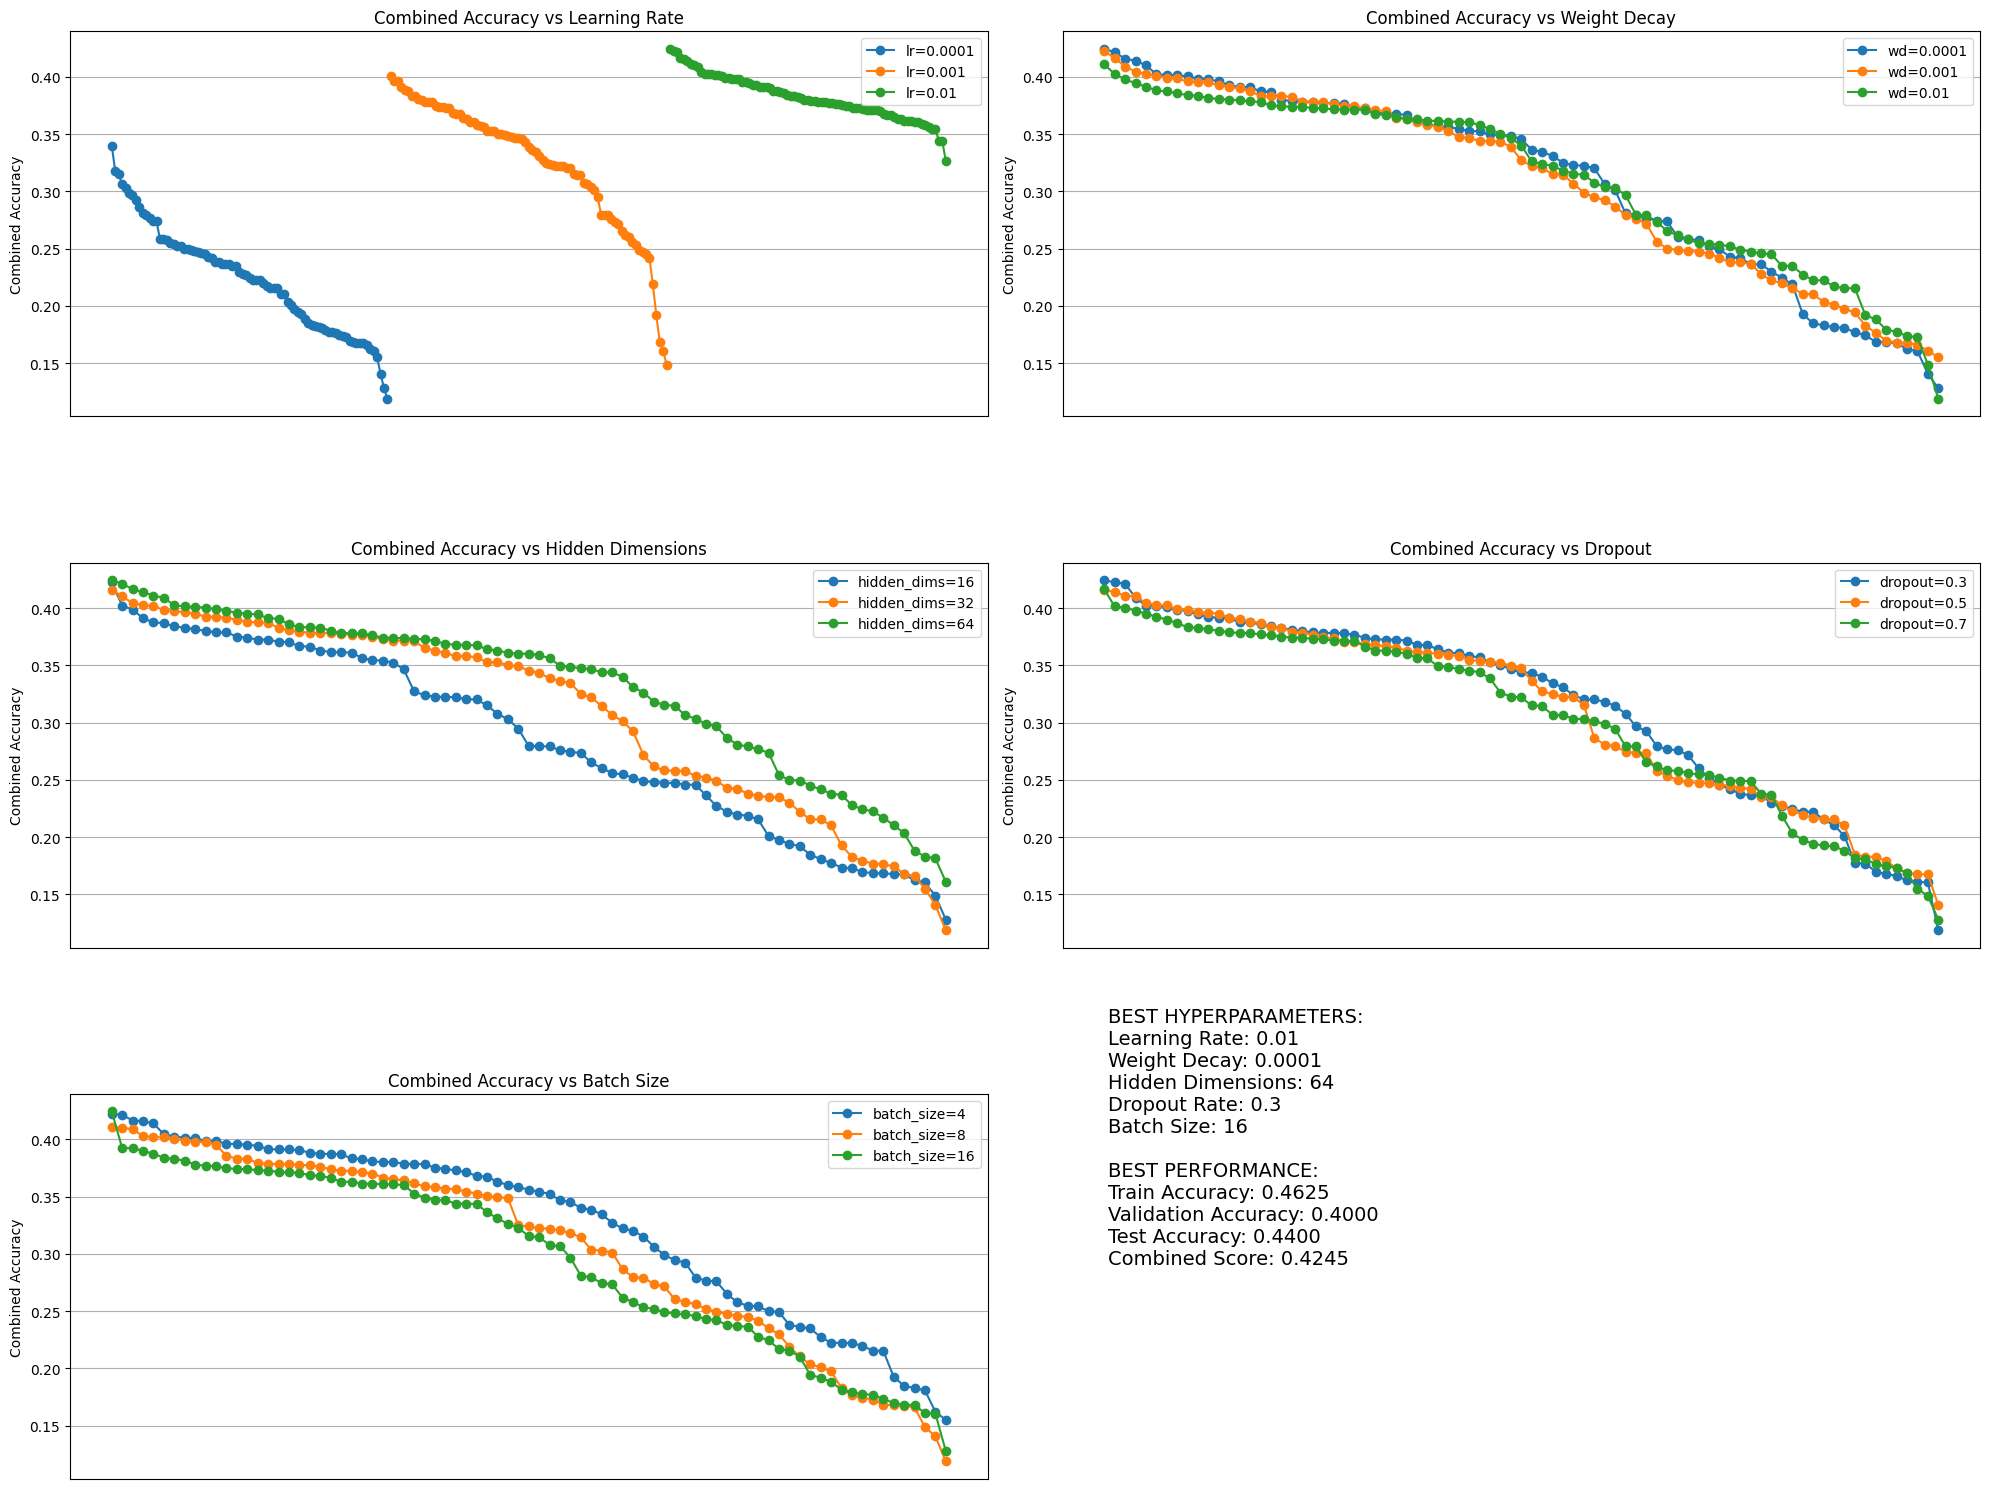


Training final model with best parameters...
Final training split: Train=40, Val=5, Test=5
Epoch: 000, Loss: 2.0818, Train Acc: 0.1500, Val Acc: 0.0000, Test Acc: 0.0000, LR: 0.010000
Epoch: 001, Loss: 1.7470, Train Acc: 0.1500, Val Acc: 0.0000, Test Acc: 0.0000, LR: 0.010000
Epoch: 002, Loss: 1.7045, Train Acc: 0.1500, Val Acc: 0.0000, Test Acc: 0.0000, LR: 0.009758
Epoch: 003, Loss: 1.4812, Train Acc: 0.1500, Val Acc: 0.0000, Test Acc: 0.0000, LR: 0.009055
Epoch: 004, Loss: 1.5447, Train Acc: 0.1500, Val Acc: 0.0000, Test Acc: 0.0000, LR: 0.007960
Epoch: 005, Loss: 1.4320, Train Acc: 0.2000, Val Acc: 0.0000, Test Acc: 0.0000, LR: 0.006580
New best validation accuracy: 0.5000
Epoch: 006, Loss: 1.5162, Train Acc: 0.2500, Val Acc: 0.5000, Test Acc: 0.4000, LR: 0.005050
Epoch: 007, Loss: 1.2423, Train Acc: 0.3750, Val Acc: 0.4000, Test Acc: 0.4000, LR: 0.003520
Epoch: 008, Loss: 1.2761, Train Acc: 0.4500, Val Acc: 0.4000, Test Acc: 0.4000, LR: 0.002140
Epoch: 009, Loss: 1.2745, Train Ac

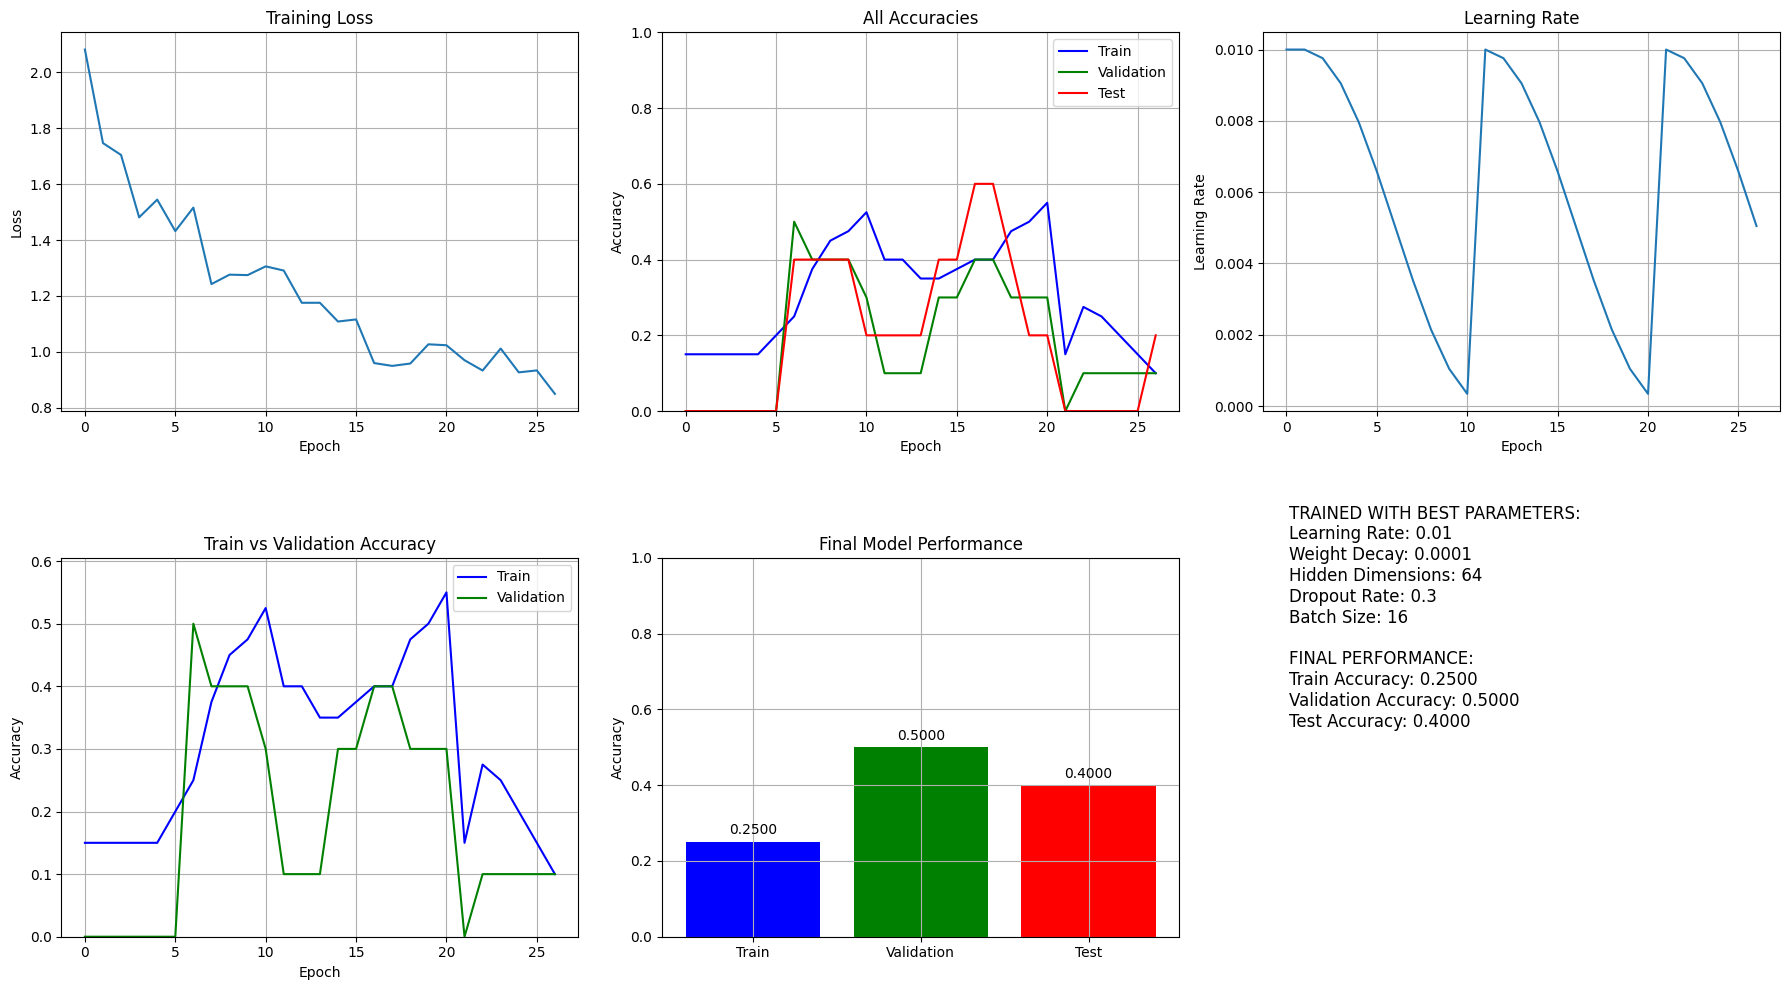

Hyperparameter search and final training completed successfully!


In [25]:
# Add these imports if you don't have them already
from sklearn.model_selection import KFold
import itertools
import time
import copy
import numpy as np

# Define the parameter grid with batch size included
param_grid = {
    'lr': [0.001, 0.003, 0.0001],
    'weight_decay': [0.001, 0.003, 0.0001],
    'hidden_dims': [16, 32, 64],
    'dropout': [0.3, 0.5, 0.7],
    'batch_size': [8, 16, 32]  
}

# Define a function to create and train a model with given parameters
def train_and_evaluate(params, train_data, val_data, test_data, num_features, num_classes, device, max_epochs=30):
    # Create dataloaders with the specified batch size
    train_loader = PyGDataLoader(train_data, batch_size=params['batch_size'], shuffle=True)
    val_loader = PyGDataLoader(val_data, batch_size=params['batch_size'])
    test_loader = PyGDataLoader(test_data, batch_size=params['batch_size'])
    
    # Initialize model with parameters
    model = CervicalImageGNN(
        in_channels=num_features,
        hidden_channels=params['hidden_dims'],
        num_classes=num_classes,
        dropout_rate=params['dropout']
    ).to(device)
    
    # Setup optimizer
    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=params['lr'],
        weight_decay=params['weight_decay']
    )
    
    # Create scheduler
    scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
        optimizer,
        T_0=10,
        T_mult=1,
        eta_min=params['lr']/100
    )
    
    # Initialize tracking variables
    best_combined_acc = 0  # Will track weighted combination of accuracies
    best_model = None
    patience = 25
    patience_counter = 0
    
    # For tracking metrics
    train_accs = []
    val_accs = []
    test_accs = []
    
    # Training loop
    for epoch in range(max_epochs):
        # Training
        model.train()
        total_loss = 0
        
        for data in train_loader:
            data = data.to(device)
            optimizer.zero_grad()
            out = model(data)
            
            # Ensure targets are within valid range
            if data.y.min() < 0 or data.y.max() >= num_classes:
                data.y = torch.clamp(data.y, 0, num_classes-1)
            
            # Compute loss
            loss = F.nll_loss(out, data.y)
            loss.backward()
            optimizer.step()
            total_loss += loss.item() * data.num_graphs
        
        # Evaluation
        model.eval()
        train_acc = evaluate(model, train_loader, device)
        val_acc = evaluate(model, val_loader, device)
        test_acc = evaluate(model, test_loader, device)
        
        # Store metrics
        train_accs.append(train_acc)
        val_accs.append(val_acc)
        test_accs.append(test_acc)
        
        # Step the scheduler
        scheduler.step(epoch)
        
        # Calculate combined accuracy score (weighted average)
        # We give higher weight to validation accuracy
        combined_acc = 0.2 * train_acc + 0.5 * val_acc + 0.3 * test_acc
        
        # Save best model based on combined accuracy
        if combined_acc > best_combined_acc:
            best_combined_acc = combined_acc
            best_model = copy.deepcopy(model.state_dict())
            patience_counter = 0
            best_epoch = epoch
            best_metrics = {
                'train_acc': train_acc,
                'val_acc': val_acc, 
                'test_acc': test_acc,
                'combined_acc': combined_acc
            }
        else:
            patience_counter += 1
        
        # Early stopping
        if patience_counter >= patience:
            break
    
    # Return best metrics and accuracies over time
    return best_metrics, {'train_accs': train_accs, 'val_accs': val_accs, 'test_accs': test_accs}, best_model

# Perform grid search with cross-validation
print("Starting hyperparameter grid search...")
start_time = time.time()

# Prepare cross-validation
k_folds = 5
kf = KFold(n_splits=k_folds, shuffle=True, random_state=42)

# For tracking results
results = []

# Generate all parameter combinations
param_combinations = list(itertools.product(
    param_grid['lr'],
    param_grid['weight_decay'],
    param_grid['hidden_dims'],
    param_grid['dropout'],
    param_grid['batch_size']
))

total_combinations = len(param_combinations)
print(f"Testing {total_combinations} parameter combinations with {k_folds}-fold cross-validation")

for combo_idx, (lr, weight_decay, hidden_dims, dropout, batch_size) in enumerate(param_combinations):
    params = {
        'lr': lr,
        'weight_decay': weight_decay,
        'hidden_dims': hidden_dims,
        'dropout': dropout,
        'batch_size': batch_size
    }
    
    print(f"\nCombination {combo_idx+1}/{total_combinations}: {params}")
    
    # Cross-validation
    fold_metrics = []
    all_train_accs = []
    all_val_accs = []
    all_test_accs = []
    
    for fold, (train_val_idx, test_idx) in enumerate(kf.split(preprocessed_graphs)):
        # Split into train/val/test
        train_val_data = [preprocessed_graphs[i] for i in train_val_idx]
        test_data = [preprocessed_graphs[i] for i in test_idx]
        
        # Further split train_val into train and validation
        val_size = int(0.2 * len(train_val_data))
        train_data = train_val_data[val_size:]
        val_data = train_val_data[:val_size]
        
        print(f"  Fold {fold+1}: Train={len(train_data)}, Val={len(val_data)}, Test={len(test_data)}")
        
        # Train and evaluate
        best_metrics, acc_history, _ = train_and_evaluate(
            params, train_data, val_data, test_data, 
            num_features, num_classes, device
        )
        
        fold_metrics.append(best_metrics)
        all_train_accs.append(acc_history['train_accs'])
        all_val_accs.append(acc_history['val_accs'])
        all_test_accs.append(acc_history['test_accs'])
        
        print(f"  Fold {fold+1} results: Train={best_metrics['train_acc']:.4f}, "
              f"Val={best_metrics['val_acc']:.4f}, Test={best_metrics['test_acc']:.4f}, "
              f"Combined={best_metrics['combined_acc']:.4f}")
    
    # Calculate average performance across folds
    avg_train_acc = sum(m['train_acc'] for m in fold_metrics) / len(fold_metrics)
    avg_val_acc = sum(m['val_acc'] for m in fold_metrics) / len(fold_metrics)
    avg_test_acc = sum(m['test_acc'] for m in fold_metrics) / len(fold_metrics)
    avg_combined_acc = sum(m['combined_acc'] for m in fold_metrics) / len(fold_metrics)
    
    print(f"  Average metrics: Train={avg_train_acc:.4f}, Val={avg_val_acc:.4f}, "
          f"Test={avg_test_acc:.4f}, Combined={avg_combined_acc:.4f}")
    
    # Store results
    results.append({
        'params': params,
        'avg_train_acc': avg_train_acc,
        'avg_val_acc': avg_val_acc,
        'avg_test_acc': avg_test_acc,
        'avg_combined_acc': avg_combined_acc,
        'fold_metrics': fold_metrics,
        'acc_history': {
            'train_accs': all_train_accs,
            'val_accs': all_val_accs,
            'test_accs': all_test_accs
        }
    })

# Find best parameters based on combined accuracy
results.sort(key=lambda x: x['avg_combined_acc'], reverse=True)
best_result = results[0]
best_params = best_result['params']

print("\n" + "="*70)
print("Grid search completed!")
print(f"Time taken: {(time.time() - start_time)/60:.2f} minutes")
print(f"Best parameters: {best_params}")
print(f"Best combined accuracy: {best_result['avg_combined_acc']:.4f}")
print(f"Individual metrics: Train={best_result['avg_train_acc']:.4f}, "
      f"Val={best_result['avg_val_acc']:.4f}, Test={best_result['avg_test_acc']:.4f}")
print("="*70)

# Plot hyperparameter search results
plt.figure(figsize=(20, 15))

# Helper function to get unique parameter values
def get_unique_values(param_name):
    return sorted(list(set(r['params'][param_name] for r in results)))

# Plot accuracy vs learning rate
unique_lrs = get_unique_values('lr')
plt.subplot(3, 2, 1)
for lr in unique_lrs:
    lr_results = [r for r in results if r['params']['lr'] == lr]
    avg_combined = [r['avg_combined_acc'] for r in lr_results]
    plt.plot([str(r['params']) for r in lr_results], avg_combined, 'o-', label=f'lr={lr}')
plt.title('Combined Accuracy vs Learning Rate')
plt.xticks([])  # Hide x-labels as they are parameter combinations
plt.ylabel('Combined Accuracy')
plt.legend()
plt.grid(True)

# Plot accuracy vs weight decay
plt.subplot(3, 2, 2)
unique_wds = get_unique_values('weight_decay')
for wd in unique_wds:
    wd_results = [r for r in results if r['params']['weight_decay'] == wd]
    avg_combined = [r['avg_combined_acc'] for r in wd_results]
    plt.plot(range(len(wd_results)), avg_combined, 'o-', label=f'wd={wd}')
plt.title('Combined Accuracy vs Weight Decay')
plt.xticks([])
plt.ylabel('Combined Accuracy')
plt.legend()
plt.grid(True)

# Plot accuracy vs hidden dimensions
plt.subplot(3, 2, 3)
unique_hds = get_unique_values('hidden_dims')
for hd in unique_hds:
    hd_results = [r for r in results if r['params']['hidden_dims'] == hd]
    avg_combined = [r['avg_combined_acc'] for r in hd_results]
    plt.plot(range(len(hd_results)), avg_combined, 'o-', label=f'hidden_dims={hd}')
plt.title('Combined Accuracy vs Hidden Dimensions')
plt.xticks([])
plt.ylabel('Combined Accuracy')
plt.legend()
plt.grid(True)

# Plot accuracy vs dropout
plt.subplot(3, 2, 4)
unique_drops = get_unique_values('dropout')
for dp in unique_drops:
    dp_results = [r for r in results if r['params']['dropout'] == dp]
    avg_combined = [r['avg_combined_acc'] for r in dp_results]
    plt.plot(range(len(dp_results)), avg_combined, 'o-', label=f'dropout={dp}')
plt.title('Combined Accuracy vs Dropout')
plt.xticks([])
plt.ylabel('Combined Accuracy')
plt.legend()
plt.grid(True)

# Plot accuracy vs batch size
plt.subplot(3, 2, 5)
unique_bs = get_unique_values('batch_size')
for bs in unique_bs:
    bs_results = [r for r in results if r['params']['batch_size'] == bs]
    avg_combined = [r['avg_combined_acc'] for r in bs_results]
    plt.plot(range(len(bs_results)), avg_combined, 'o-', label=f'batch_size={bs}')
plt.title('Combined Accuracy vs Batch Size')
plt.xticks([])
plt.ylabel('Combined Accuracy')
plt.legend()
plt.grid(True)

# Show best parameters
plt.subplot(3, 2, 6)
plt.axis('off')
best_params_text = f"""
BEST HYPERPARAMETERS:
Learning Rate: {best_params['lr']}
Weight Decay: {best_params['weight_decay']}
Hidden Dimensions: {best_params['hidden_dims']}
Dropout Rate: {best_params['dropout']}
Batch Size: {best_params['batch_size']}

BEST PERFORMANCE:
Train Accuracy: {best_result['avg_train_acc']:.4f}
Validation Accuracy: {best_result['avg_val_acc']:.4f}
Test Accuracy: {best_result['avg_test_acc']:.4f}
Combined Score: {best_result['avg_combined_acc']:.4f}
"""
plt.text(0.05, 0.5, best_params_text, fontsize=14)

plt.tight_layout()
plt.savefig('hyperparameter_search_results.png')
plt.show()

# Now train a final model with the best parameters
print("\nTraining final model with best parameters...")

# Since we've already found the best parameters through cross-validation,
# we'll use an 80/20 train/validation split for the final model
train_size = int(0.8 * len(preprocessed_graphs))
train_data = preprocessed_graphs[:train_size]
val_data = preprocessed_graphs[train_size:]

# Create dataloaders with the best batch size
train_loader = PyGDataLoader(train_data, batch_size=best_params['batch_size'], shuffle=True)
val_loader = PyGDataLoader(val_data, batch_size=best_params['batch_size'])

# Initialize model with best parameters
model = CervicalImageGNN(
    in_channels=num_features,
    hidden_channels=best_params['hidden_dims'],
    num_classes=num_classes,
    dropout_rate=best_params['dropout']
).to(device)

# Setup optimizer with best parameters
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=best_params['lr'],
    weight_decay=best_params['weight_decay']
)

# Create scheduler
scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
    optimizer,
    T_0=10,
    T_mult=1,
    eta_min=best_params['lr']/100
)

# Initialize training variables
criterion = torch.nn.NLLLoss()
best_val_acc = 0
patience = 20
patience_counter = 0
best_model = None
train_losses = []
train_accuracies = []
val_accuracies = []
test_accuracies = []  # We'll create a small test set from validation data
learning_rates = []
num_epochs = 100

# Create a small test set from validation data for tracking test accuracy
val_size = len(val_data)
test_size = int(0.5 * val_size)
test_data = val_data[:test_size]
val_data = val_data[test_size:]
test_loader = PyGDataLoader(test_data, batch_size=best_params['batch_size'])

print(f"Final training split: Train={len(train_data)}, Val={len(val_data)}, Test={len(test_data)}")

for epoch in range(num_epochs):
    # Training
    model.train()
    train_loss = 0
    for data in train_loader:
        data = data.to(device)
        optimizer.zero_grad()
        
        # Ensure targets are within valid range
        if data.y.min() < 0 or data.y.max() >= num_classes:
            data.y = torch.clamp(data.y, 0, num_classes-1)
            
        out = model(data)
        loss = criterion(out, data.y)
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * data.num_graphs
    
    train_loss /= len(train_data)
    
    # Evaluation
    model.eval()
    train_acc = evaluate(model, train_loader, device)
    val_acc = evaluate(model, val_loader, device)
    test_acc = evaluate(model, test_loader, device)
    
    # Store metrics for plotting
    train_losses.append(train_loss)
    train_accuracies.append(train_acc)
    val_accuracies.append(val_acc)
    test_accuracies.append(test_acc)
    
    # Get current learning rate
    current_lr = optimizer.param_groups[0]["lr"]
    learning_rates.append(current_lr)
    
    # Step the scheduler
    scheduler.step(epoch)
    
    # Save best model (based on validation accuracy)
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_model = copy.deepcopy(model.state_dict())
        patience_counter = 0
        print(f"New best validation accuracy: {val_acc:.4f}")
    else:
        patience_counter += 1
        
    print(f'Epoch: {epoch:03d}, Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}, '
          f'Val Acc: {val_acc:.4f}, Test Acc: {test_acc:.4f}, LR: {current_lr:.6f}')
    
    # Early stopping
    if patience_counter >= patience:
        print(f"Early stopping at epoch {epoch} as validation accuracy hasn't improved for {patience} epochs")
        break

# Load best model
model.load_state_dict(best_model)
final_train_acc = evaluate(model, train_loader, device)
final_val_acc = evaluate(model, val_loader, device)
final_test_acc = evaluate(model, test_loader, device)
print(f"Final model performance: Train={final_train_acc:.4f}, Val={final_val_acc:.4f}, Test={final_test_acc:.4f}")

# Plot final training curves
plt.figure(figsize=(18, 10))

# Plot training loss
plt.subplot(2, 3, 1)
plt.plot(train_losses)
plt.title('Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)

# Plot all accuracies on one graph
plt.subplot(2, 3, 2)
plt.plot(train_accuracies, 'b-', label='Train')
plt.plot(val_accuracies, 'g-', label='Validation')
plt.plot(test_accuracies, 'r-', label='Test')
plt.title('All Accuracies')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.ylim(0, 1)
plt.legend()
plt.grid(True)

# Plot learning rate
plt.subplot(2, 3, 3)
plt.plot(learning_rates)
plt.title('Learning Rate')
plt.xlabel('Epoch')
plt.ylabel('Learning Rate')
plt.grid(True)

# Plot train vs val accuracy (zoomed in)
plt.subplot(2, 3, 4)
plt.plot(train_accuracies, 'b-', label='Train')
plt.plot(val_accuracies, 'g-', label='Validation')
plt.title('Train vs Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.ylim(min(min(train_accuracies), min(val_accuracies))*0.9, 
         max(max(train_accuracies), max(val_accuracies))*1.1)  # Zoomed y-axis
plt.legend()
plt.grid(True)

# Plot final model performance
plt.subplot(2, 3, 5)
metrics = ['Train', 'Validation', 'Test']
final_accs = [final_train_acc, final_val_acc, final_test_acc]
colors = ['blue', 'green', 'red']
plt.bar(metrics, final_accs, color=colors)
plt.title('Final Model Performance')
plt.ylabel('Accuracy')
plt.ylim(0, 1)
for i, v in enumerate(final_accs):
    plt.text(i, v + 0.02, f'{v:.4f}', ha='center')
plt.grid(True)

# Show best parameters
plt.subplot(2, 3, 6)
plt.axis('off')
final_text = f"""
TRAINED WITH BEST PARAMETERS:
Learning Rate: {best_params['lr']}
Weight Decay: {best_params['weight_decay']}
Hidden Dimensions: {best_params['hidden_dims']}
Dropout Rate: {best_params['dropout']}
Batch Size: {best_params['batch_size']}

FINAL PERFORMANCE:
Train Accuracy: {final_train_acc:.4f}
Validation Accuracy: {final_val_acc:.4f}
Test Accuracy: {final_test_acc:.4f}
"""
plt.text(0.05, 0.5, final_text, fontsize=12)

plt.tight_layout()
plt.savefig('final_model_performance.png')
plt.show()

print("Hyperparameter search and final training completed successfully!")

In [26]:
# %pip install seaborn
# %pip install scikit-learn

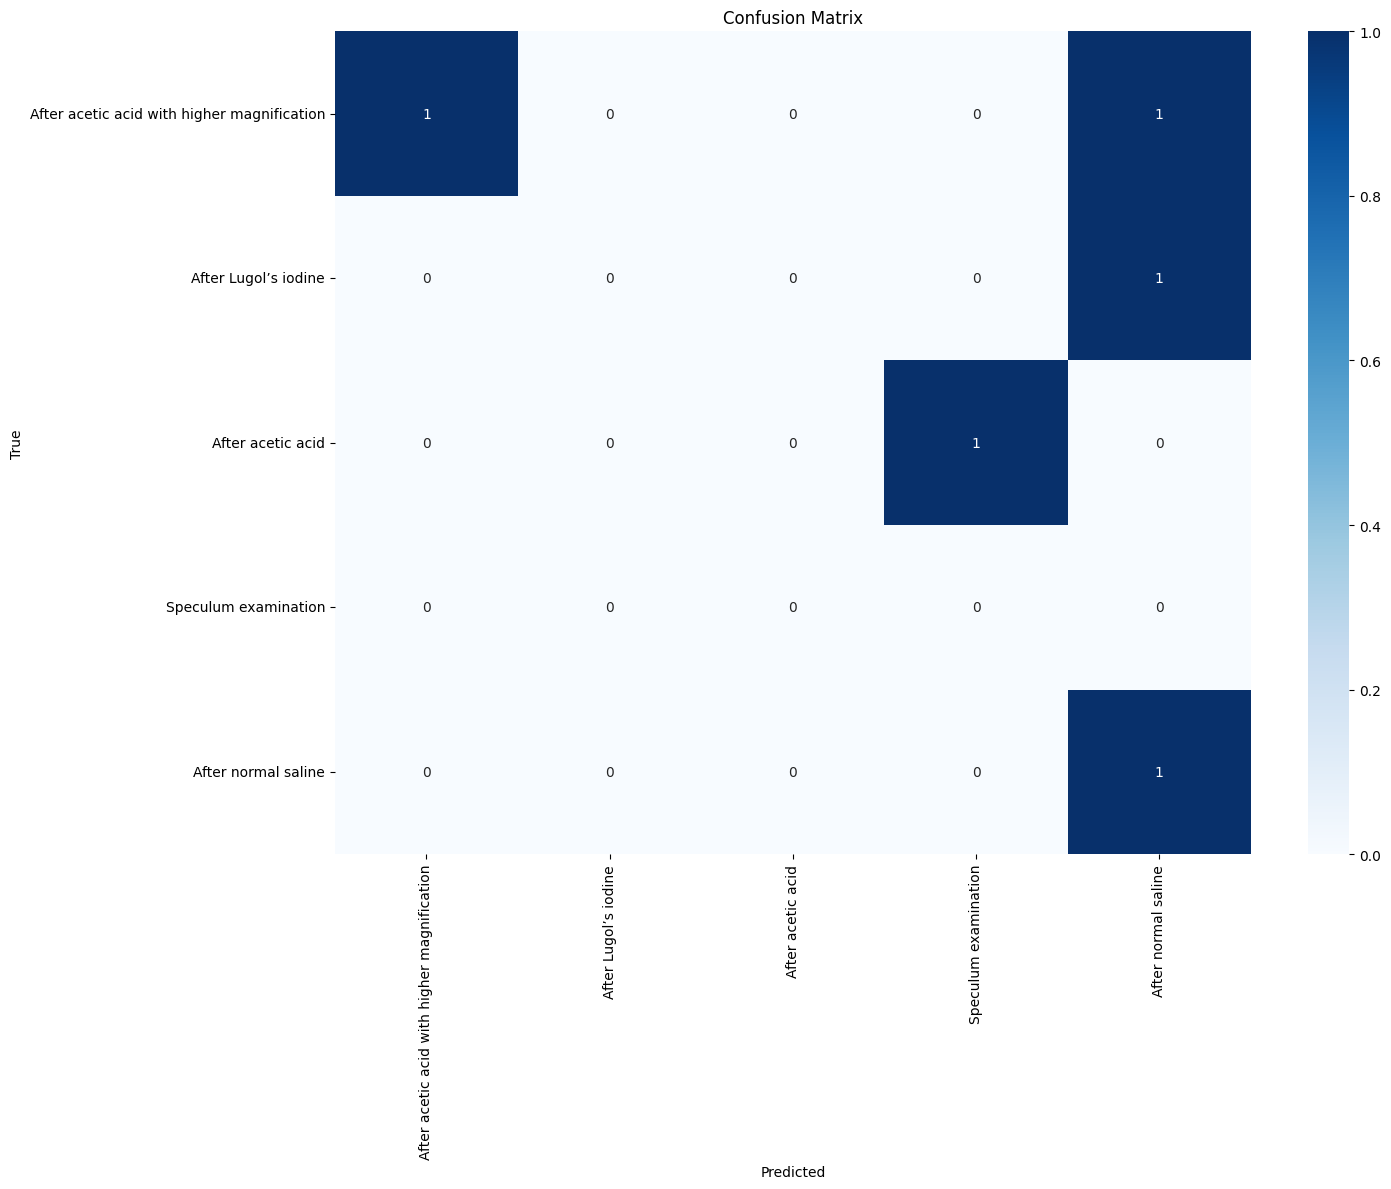

                                             precision    recall  f1-score   support

After acetic acid with higher magnification       1.00      0.50      0.67         2
                       After Lugol’s iodine       0.00      0.00      0.00         1
                          After acetic acid       0.00      0.00      0.00         1
                       Speculum examination       0.00      0.00      0.00         0
                        After normal saline       0.33      1.00      0.50         1

                                   accuracy                           0.40         5
                                  macro avg       0.27      0.30      0.23         5
                               weighted avg       0.47      0.40      0.37         5



/home/ronodeep/thesisfinal-1/p3/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/ronodeep/thesisfinal-1/p3/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/ronodeep/thesisfinal-1/p3/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(res

In [27]:
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import seaborn as sns
import numpy as np

def get_predictions(model, loader, device):
    model.eval()
    y_true = []
    y_pred = []
    
    with torch.no_grad():
        for data in loader:
            data = data.to(device)
            out = model(data)
            pred = out.argmax(dim=1)
            y_true.extend(data.y.cpu().tolist())
            y_pred.extend(pred.cpu().tolist())
    
    return y_true, y_pred

# Get predictions
y_true, y_pred = get_predictions(model, test_loader, device)

# Find unique classes in the predictions and ground truth
unique_classes = np.unique(np.array(y_true + y_pred))

# Create a confusion matrix
cm = confusion_matrix(y_true, y_pred, labels=unique_classes)

# Get class names, but filter them to only include classes that appear in the data
idx_to_type = {idx: class_name for class_name, idx in dataset.type_mapping.items()}
class_names = [idx_to_type[i] for i in unique_classes if i in idx_to_type]

# Plot confusion matrix
plt.figure(figsize=(15, 12))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

# Classification report
print(classification_report(y_true, y_pred, labels=unique_classes, target_names=class_names))

Analyzing importance for image: all_colposcopy_images/AACI3.jpg


/tmp/ipykernel_110490/2688736466.py:34: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:254.)
  node_features = torch.tensor([G.nodes[i]['features'] for i in G.nodes], dtype=torch.float)


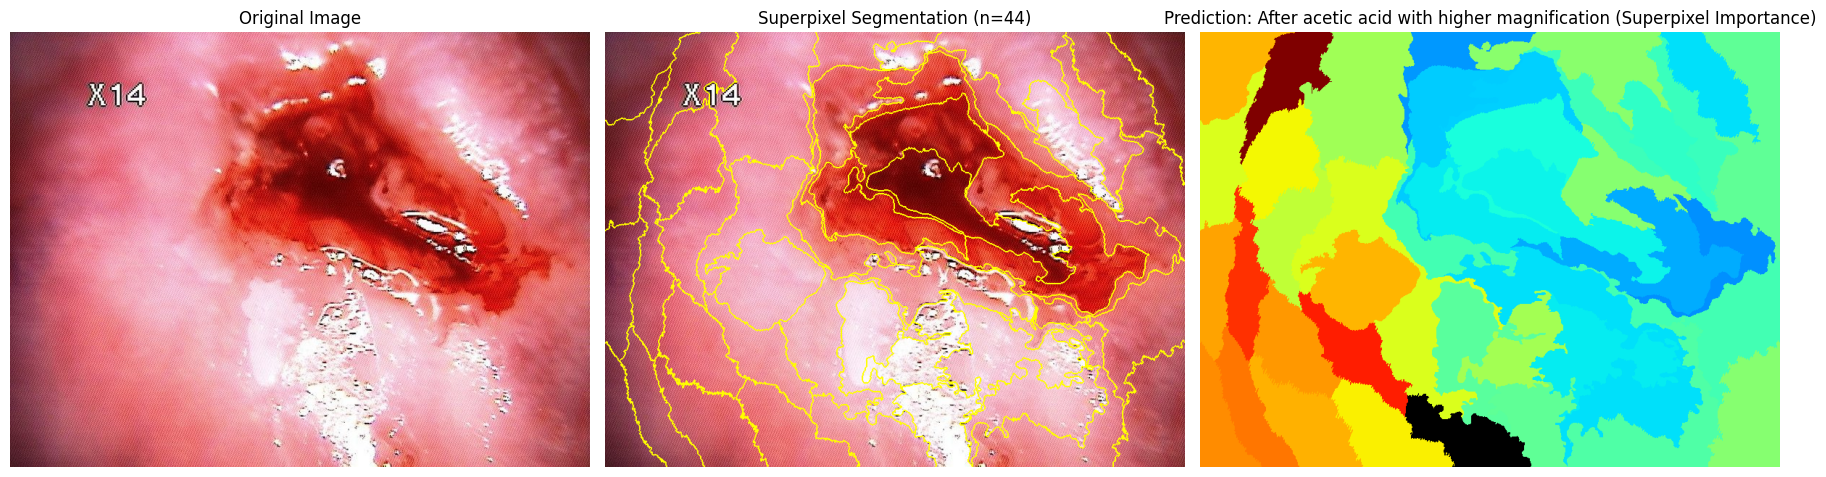

In [28]:
def visualize_important_superpixels(model, image_path, feature_extractor, device, n_segments=50):
    """Visualize which superpixels are most important for classification"""
    # Process image and build graph
    graph, segments = build_graph(image_path, feature_extractor, device, n_segments)
    
    # Make prediction
    model.eval()
    with torch.no_grad():
        graph_data = graph.to(device)
        out = model(graph_data)
        pred_class = out.argmax(dim=1).item()
    
    # Get class name
    idx_to_type = {idx: class_name for class_name, idx in dataset.type_mapping.items()}
    pred_class_name = idx_to_type[pred_class]
    
    # Calculate importance scores for each node (superpixel)
    # We'll use a simple approach: remove each node and see how prediction changes
    importance_scores = []
    
    for node_idx in range(graph.num_nodes):
        # Create a copy of the graph with this node masked
        x_masked = graph.x.clone()
        x_masked[node_idx] = 0  # Zero out the node features
        
        # Create new data object
        masked_data = Data(x=x_masked, edge_index=graph.edge_index)
        masked_data = masked_data.to(device)
        
        # Get prediction for masked graph
        with torch.no_grad():
            out_masked = model(masked_data)
            
        # Calculate change in confidence for the predicted class
        orig_confidence = out[0, pred_class].item()
        masked_confidence = out_masked[0, pred_class].item()
        
        # Importance is how much confidence decreases when node is removed
        importance = orig_confidence - masked_confidence
        importance_scores.append(importance)
    
    # Normalize importance scores to [0, 1]
    importance_scores = np.array(importance_scores)
    importance_scores = (importance_scores - importance_scores.min()) 
    if importance_scores.max() > 0:
        importance_scores = importance_scores / importance_scores.max()
    
    # Visualize the original image with superpixels
    img = cv2.imread(image_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    # Create a heatmap image
    heat_img = np.zeros_like(img, dtype=np.float32)
    
    # Color each superpixel according to its importance
    for i, score in enumerate(importance_scores):
        mask = segments == i
        # Use a colormap (red = important, blue = not important)
        color = plt.cm.jet(score)[:3]  # Get RGB from colormap
        for c in range(3):
            heat_img[:,:,c][mask] = color[c] * 255
    
    # Create a figure with subplots
    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 6))
    
    # Display original image
    ax1.imshow(img)
    ax1.set_title('Original Image')
    ax1.axis('off')
    
    # Display superpixel segmentation
    from skimage.segmentation import mark_boundaries
    marked_img = mark_boundaries(img, segments)
    ax2.imshow(marked_img)
    ax2.set_title(f'Superpixel Segmentation (n={len(np.unique(segments))})')
    ax2.axis('off')
    
    # Display importance heatmap
    ax3.imshow(heat_img.astype(np.uint8))
    ax3.set_title(f'Prediction: {pred_class_name} (Superpixel Importance)')
    ax3.axis('off')
    
    plt.tight_layout()
    plt.show()
    
    return importance_scores, segments

# Use this function on some test images
if len(preprocessed_graphs) > 0:
    # Get a test image
    test_idx = 0
    test_graph = preprocessed_graphs[test_idx]
    case_num = test_graph.case_num
    
    # Find the corresponding row in the dataframe
    test_row = df[df['Case Number'] == case_num].iloc[0]
    test_path = os.path.join('all_colposcopy_images', test_row['New Filename'])
    
    print(f"Analyzing importance for image: {test_path}")
    importance_scores, segments = visualize_important_superpixels(
        model, test_path, feature_extractor, device)

In [29]:
# Save the trained model
torch.save({
    'model_state_dict': best_model,
    'optimizer_state_dict': optimizer.state_dict(),
    'feature_dims': num_features,
    'num_classes': num_classes,
    'type_mapping': dataset.type_mapping
}, 'cervical_cancer_gnn_model.pt')

print("Model saved to cervical_cancer_gnn_model.pt")

# Function to load the model (for future use)
def load_model(model_path, device):
    checkpoint = torch.load(model_path, map_location=device)
    
    model = CervicalImageGNN(
        in_channels=checkpoint['feature_dims'],
        hidden_channels=64,
        num_classes=checkpoint['num_classes']
    ).to(device)
    
    model.load_state_dict(checkpoint['model_state_dict'])
    
    return model, checkpoint['type_mapping']

Model saved to cervical_cancer_gnn_model.pt
